# Análisis de Datos - Titanic

**Equipo:** Santiago Calle – Alexander Luna  - Alvaro Quisilema   
**Programa:** Maestría en Ciencia de Datos y Máquinas de Aprendizaje  
**Fecha:** 2 de junio 2026

**Objetivo:** Realizar el preprocesamiento y análisis exploratorio de datos (EDA) del dataset de cáncer de mama para el propósito de predicción (Maligno vs Benigno).

---
## FASE I - Preprocesamiento de Datos

### 1. Importar librerías

In [1]:
# Librerías principales
import numpy as np
import pandas as pd

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Normalización
from sklearn.preprocessing import MinMaxScaler

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

### 2. Cargar el conjunto de datos

In [2]:
# URLs de los archivos CSV en GitHub
train_path = "https://raw.githubusercontent.com/Alexander-Luna/UIDE-HERRAMIENTAS-PARA-DATA-SCIENCE/7b5787fb96e704d9d28628345521753520457334/Semana1/titanic_train.csv"
test_path = 'https://raw.githubusercontent.com/Alexander-Luna/UIDE-HERRAMIENTAS-PARA-DATA-SCIENCE/7b5787fb96e704d9d28628345521753520457334/Semana1/titanic_test.csv'

# Leer los archivos CSV
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print('--- Dataset de Entrenamiento (primeras 5 filas) ---')
print(df_train.head())
print(f'\nDimensiones: {df_train.shape}')

print('\n--- Dataset de Prueba (primeras 5 filas) ---')
print(df_test.head())
print(f'\nDimensiones: {df_test.shape}')

--- Dataset de Entrenamiento (primeras 5 filas) ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4  

### 3. Entendimiento de los datos

In [3]:
# Información general del dataset de entrenamiento
print('=== INFORMACIÓN DEL DATASET DE ENTRENAMIENTO ===')
print(df_train.info())

print('\n=== INFORMACIÓN DEL DATASET DE PRUEBA ===')
print(df_test.info())

=== INFORMACIÓN DEL DATASET DE ENTRENAMIENTO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== INFORMACIÓN DEL DATASET DE PRUEBA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  


In [4]:
# Estadísticas descriptivas del dataset de entrenamiento
print('=== ESTADÍSTICAS DESCRIPTIVAS (TRAIN) ===')
df_train.describe()

=== ESTADÍSTICAS DESCRIPTIVAS (TRAIN) ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 4. Preprocesamiento

In [5]:
########## Preprocesamiento de la data ##########

# Transforma los datos de la variable sexo (categórico) en números
df_train['Sex'].replace(['female','male'],[0,1],inplace=True)
df_test['Sex'].replace(['female','male'],[0,1],inplace=True)

#Transforma los datos de embarque (categórico) en números
df_train['Embarked'].replace(['Q','S', 'C'],[0,1,2],inplace=True)
df_test['Embarked'].replace(['Q','S', 'C'],[0,1,2],inplace=True)

#Reemplazo los datos faltantes en la edad por la media de esta variable
print(df_train["Age"].mean())
print(df_test["Age"].mean())
promedio = 30
df_train['Age'] = df_train['Age'].replace(np.nan, promedio)
df_test['Age'] = df_test['Age'].replace(np.nan, promedio)

#Crea varios grupos/rangos de edades
#Rangos de edad: 0-8, 9-15, 16-18, 19-25, 26-40, 41-60, 61-100
bins = [0, 8, 15, 18, 25, 40, 60, 100]
names = ['1', '2', '3', '4', '5', '6', '7']
df_train['Age'] = pd.cut(df_train['Age'], bins, labels = names)
df_test['Age'] = pd.cut(df_test['Age'], bins, labels = names)

#Se elimina la columna de "Cabin" ya que tiene muchos datos perdidos
# El parámetro axis=1 indica que se deben eliminar columnas en lugar de filas (axis=0).
# El parámetro inplace indica si la operación se realiza directamente en el
# DataFrame original o devolvuelve una nueva copia con filas o columnas eliminadas.
df_train.drop(['Cabin'], axis = 1, inplace=True)
df_test.drop(['Cabin'], axis = 1, inplace=True)

#Elimina las columnas que se considera que no son necesarias para el analisis
df_train = df_train.drop(['PassengerId','Name','Ticket'], axis=1)
df_test = df_test.drop(['Name','Ticket'], axis=1)

#Se elimina las filas con datos perdidos

df_train.dropna(axis=0, how='any', inplace=True)
df_test.dropna(axis=0, how='any', inplace=True)

#Verifica los datos faltantes y tamaño
print(pd.isnull(df_train).sum())
print(pd.isnull(df_test).sum())

print(df_train.shape)
print(df_test.shape)

print(df_test.head())
print(df_train.head())

# Guardar el DataFrame en un archivo CSV
# df_train.to_csv('/content/drive/MyDrive/Colab Notebooks/train_procesado2.csv', index=False, sep=',', encoding='utf-8')

29.69911764705882
30.272590361445783
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64
(889, 8)
(417, 8)
   PassengerId  Pclass  Sex Age  SibSp  Parch     Fare  Embarked
0          892       3    1   5      0      0   7.8292         0
1          893       3    0   6      1      0   7.0000         1
2          894       2    1   7      0      0   9.6875         0
3          895       3    1   5      0      0   8.6625         1
4          896       3    0   4      1      1  12.2875         1
   Survived  Pclass  Sex Age  SibSp  Parch     Fare  Embarked
0         0       3    1   4      1      0   7.2500       1.0
1         1       1    0   5      1      0  71.2833       2.0
2         1       3    0   5      0      0   7.9250       1.0
3         1       1    0   5     

/tmp/ipykernel_4701/1136186334.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Sex'].replace(['female','male'],[0,1],inplace=True)
/tmp/ipykernel_4701/1136186334.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['Sex'].replace(['female','male'],[0,1],inplace=True)
/tmp/ipyke

#### 4.4 Normalización de datos

In [6]:
# Las variables categóricas NO se normalizan; se codifican (One-Hot, Label Encoding, etc.)
from sklearn.preprocessing import MinMaxScaler

# Normalizar solo la columna Fare (la única numérica continua)
# Se usa fit_transform para el train y transform para test (buena práctica en ML)
scaler = MinMaxScaler(feature_range=(0,1))
df_train['Fare_normalized'] = scaler.fit_transform(df_train[['Fare']])
df_test['Fare_normalized'] = scaler.transform(df_test[['Fare']])

# reduce dimensiones (opcional)
df_train['SibSp_Parch'] = df_train['SibSp'] + df_train['Parch']

# (Opcional) Si deseas eliminar la columna Fare original y otras:
df_train.drop(columns=['Fare'], inplace=True)
df_train.drop(columns=['SibSp'], inplace=True)
df_train.drop(columns=['Parch'], inplace=True)
# df_test.drop(columns=['Fare'], inplace=True)

df_train.to_csv('train_procesado_2.csv', index=False, sep=',', encoding='utf-8')

---
## FASE II - Análisis Exploratorio de Datos (EDA)

### 1. Distribución de la variable objetivo (diagnosis)

Es fundamental conocer la proporción entre casos benignos y malignos para entender si existe desbalance en los datos.

In [7]:
print(df_train.head(10))

# Estadísticas descriptivas
print(df_train.describe())

# Estadísticas de variables categóricas (como 'Age' que es de tipo 'category')
print(df_train.describe(include=['category']))

   Survived  Pclass  Sex Age  Embarked  Fare_normalized  SibSp_Parch
0         0       3    1   4       1.0         0.014151            1
1         1       1    0   5       2.0         0.139136            1
2         1       3    0   5       1.0         0.015469            0
3         1       1    0   5       1.0         0.103644            1
4         0       3    1   5       1.0         0.015713            0
5         0       3    1   5       0.0         0.016510            0
6         0       1    1   6       1.0         0.101229            0
7         0       3    1   1       1.0         0.041136            4
8         1       3    0   5       1.0         0.021731            2
9         1       2    0   2       2.0         0.058694            1
         Survived      Pclass         Sex    Embarked  Fare_normalized  \
count  889.000000  889.000000  889.000000  889.000000       889.000000   
mean     0.382452    2.311586    0.649044    1.102362         0.062649   
std      0.486260  

Se observa un ligero desbalance en los datos, con mayor cantidad de casos benignos que malignos. Esto es importante tenerlo en cuenta para futuros modelos de predicción, ya que un modelo podría sesgarse hacia la clase mayoritaria.

### 2. Distribución de variables principales (Histogramas)

Se seleccionan las variables de media (`radius1`, `texture1`, `perimeter1`, `area1`, `smoothness1`, `compactness1`) por ser las mediciones directas más representativas de las características del tumor.

         Survived      Pclass         Sex    Embarked  Fare_normalized  \
count  889.000000  889.000000  889.000000  889.000000       889.000000   
mean     0.382452    2.311586    0.649044    1.102362         0.062649   
std      0.486260    0.834700    0.477538    0.515181         0.097003   
min      0.000000    1.000000    0.000000    0.000000         0.000000   
25%      0.000000    2.000000    0.000000    1.000000         0.015412   
50%      0.000000    3.000000    1.000000    1.000000         0.028213   
75%      1.000000    3.000000    1.000000    1.000000         0.060508   
max      1.000000    3.000000    1.000000    2.000000         1.000000   

       SibSp_Parch  
count   889.000000  
mean      0.906637  
std       1.614703  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       1.000000  
max      10.000000  
        Age
count   889
unique    7
top       5
freq    439


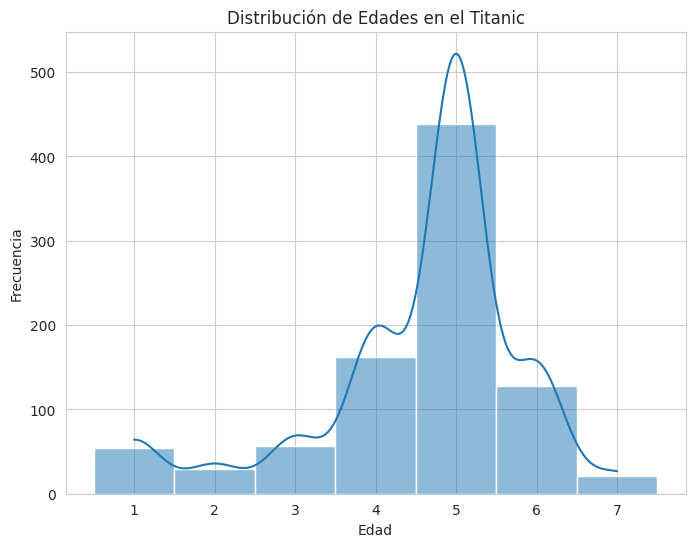

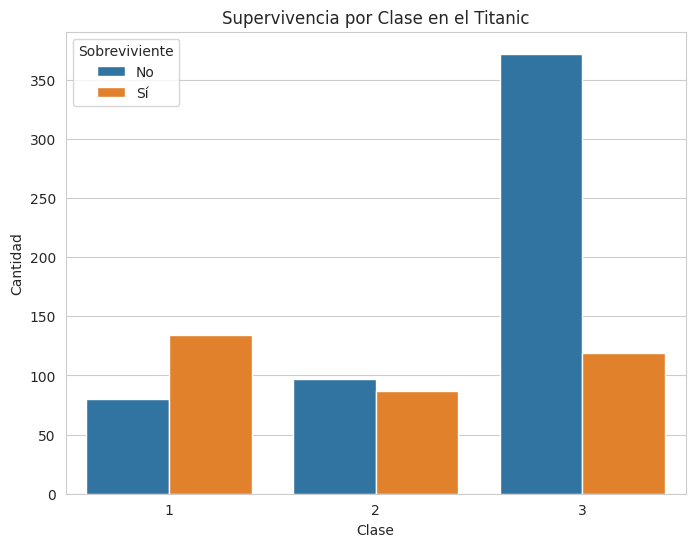

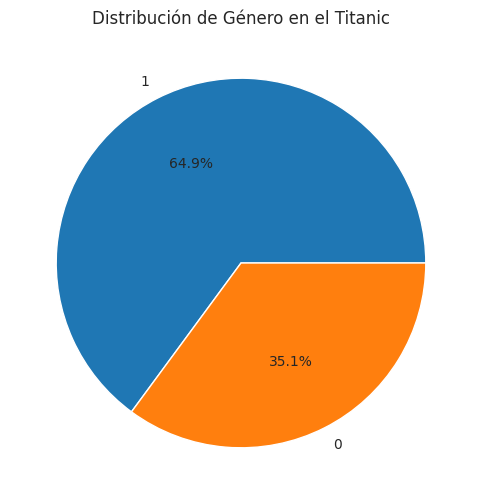

In [8]:
# Estadísticas descriptivas
print(df_train.describe())

    # Estadísticas de variables categóricas
print(df_train.describe(include=['category']))

    # Histogramas de Edades:
plt.figure(figsize=(8, 6))
sns.histplot(df_train['Age'].dropna(), bins=30, kde=True)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edades en el Titanic')
plt.show()

    # Gráfico de Barras de Supervivencia por Clase:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='Pclass', hue='Survived')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Supervivencia por Clase en el Titanic')
plt.legend(title='Sobreviviente', labels=['No', 'Sí'])
plt.show()

    # Gráfico de Torta de Género:
plt.figure(figsize=(8, 6))
df_train['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución de Género en el Titanic')
plt.ylabel('')
plt.show()


Las variables `radius1`, `perimeter1` y `area1` muestran una clara separación entre tumores benignos y malignos: los tumores malignos tienden a tener valores más altos. Esto indica que el tamaño del tumor es un factor determinante para la clasificación. Variables como `texture1` y `smoothness1` muestran mayor solapamiento entre ambas clases, lo que sugiere menor poder discriminativo por sí solas.

### 4. Matriz de correlación

La matriz de correlación nos ayuda a identificar las relaciones lineales entre variables y detectar posibles redundancias (multicolinealidad).

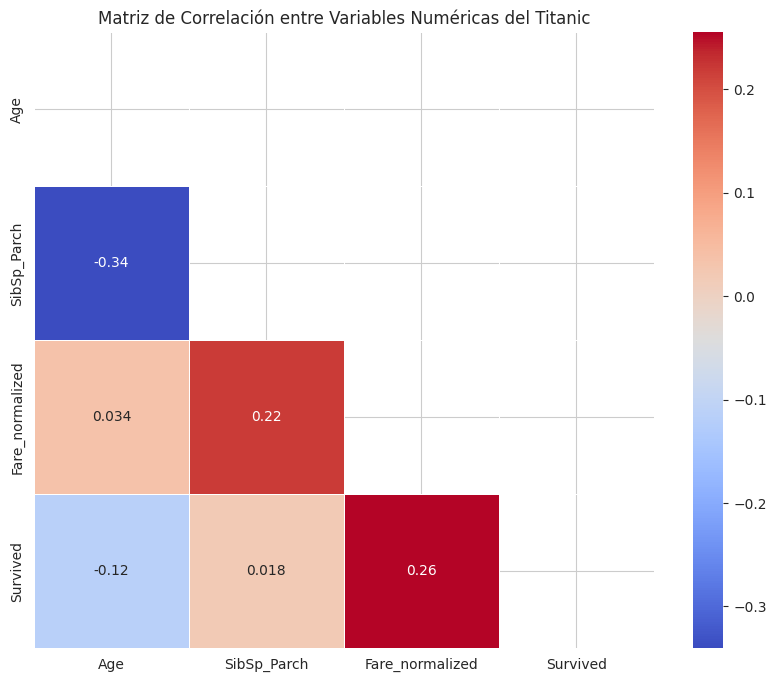

In [9]:
import numpy as np

# Análisis de Correlación
# Se podría eliminar aquellas variables que tengan una correlación baja o nula
# con la variable objetivo, ya que podrían no aportar información relevante al modelo.
# Además, se podría quitar ciertas variables que están altamente correlacionadas entre sí.

# Crear una copia temporal del DataFrame para no modificar la columna 'Age' original
df_train_for_corr = df_train.copy()

# Convertir la columna 'Age' a tipo numérico, ya que fue convertida a categórica con etiquetas de string.
df_train_for_corr['Age'] = df_train_for_corr['Age'].astype(int)

# Seleccionar las variables numéricas principales para el análisis de correlación y el target
# Actualizar la lista con los nombres de las columnas existentes y transformadas
variables_for_correlation = ['Age', 'SibSp_Parch', 'Fare_normalized', 'Survived']

# Crear una submatriz de correlación
correlation_matrix = df_train_for_corr[variables_for_correlation].corr()

# Crear una máscara para el triángulo inferior (incluyendo la diagonal)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Crear un mapa de calor de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5, mask=mask)
plt.title('Matriz de Correlación entre Variables Numéricas del Titanic')
plt.show()

# Diagrama de Cajas

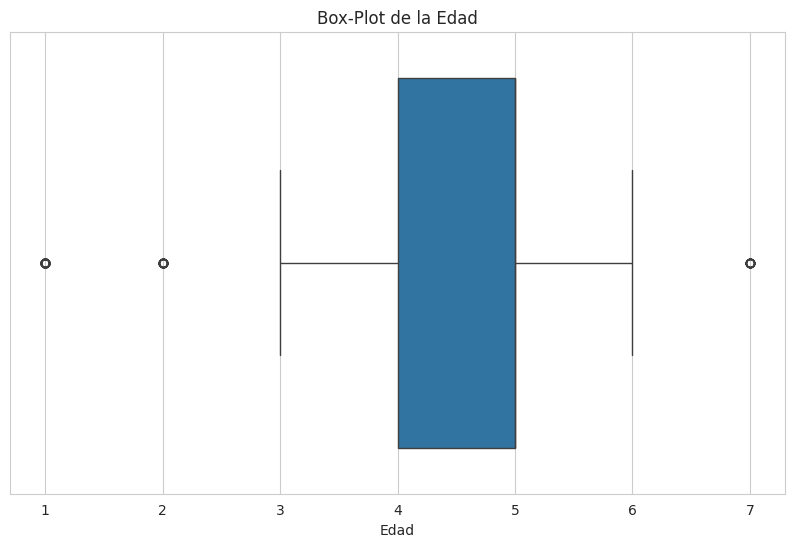

In [10]:
# Crear el box-plot de la variable "edad"
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_train['Age'])
plt.title('Box-Plot de la Edad')
plt.xlabel('Edad')
plt.show()

# Importar datos

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

In [12]:
# Preparación del conjunto de datos Titanic para el modelo
# X contendrá las características (todas las columnas excepto 'Survived')
# y contendrá la variable objetivo ('Survived')
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normaliza los datos para que todas las características tengan una escala similar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # calcula los parámetros: media y desv. estandar
X_test = scaler.transform(X_test) # usa los parámetros (media y desv. estandar) ya calculados en el training set.

MODELADO

In [13]:
# Crea y entrena el modelo de regresión logistica
model = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=100)
model.fit(X_train, y_train)

# Imprime los coeficientes y el intercepto del modelo entrenado
print("\nCoeficientes del modelo:")
print(model.coef_)
print("\nIntercepto del modelo:")
print(model.intercept_)


Coeficientes del modelo:
[[-0.84809381 -1.33223571 -0.59673655  0.08047397  0.16505644 -0.54932595]]

Intercepto del modelo:
[-0.64588555]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# Evaluación

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       109
           1       0.76      0.75      0.76        69

    accuracy                           0.81       178
   macro avg       0.81      0.80      0.80       178
weighted avg       0.81      0.81      0.81       178

confusion matrix: 
 [[93 16]
 [17 52]]


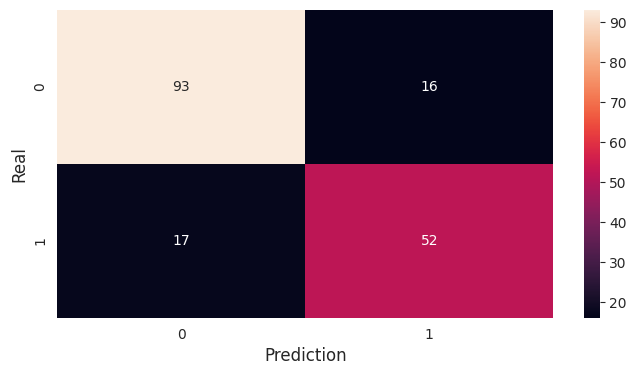

accuracy:  0.8146067415730337
recall:  0.7536231884057971
precision:  0.7647058823529411
specificity:  0.8532110091743119
f1 score:  0.7591240875912408
auc:  0.8034170987900545


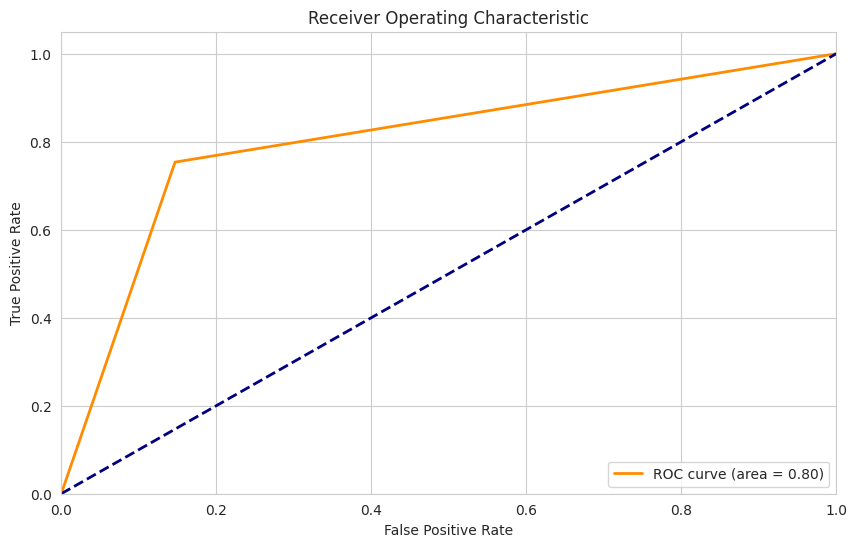

R2:  0.2189868368568011


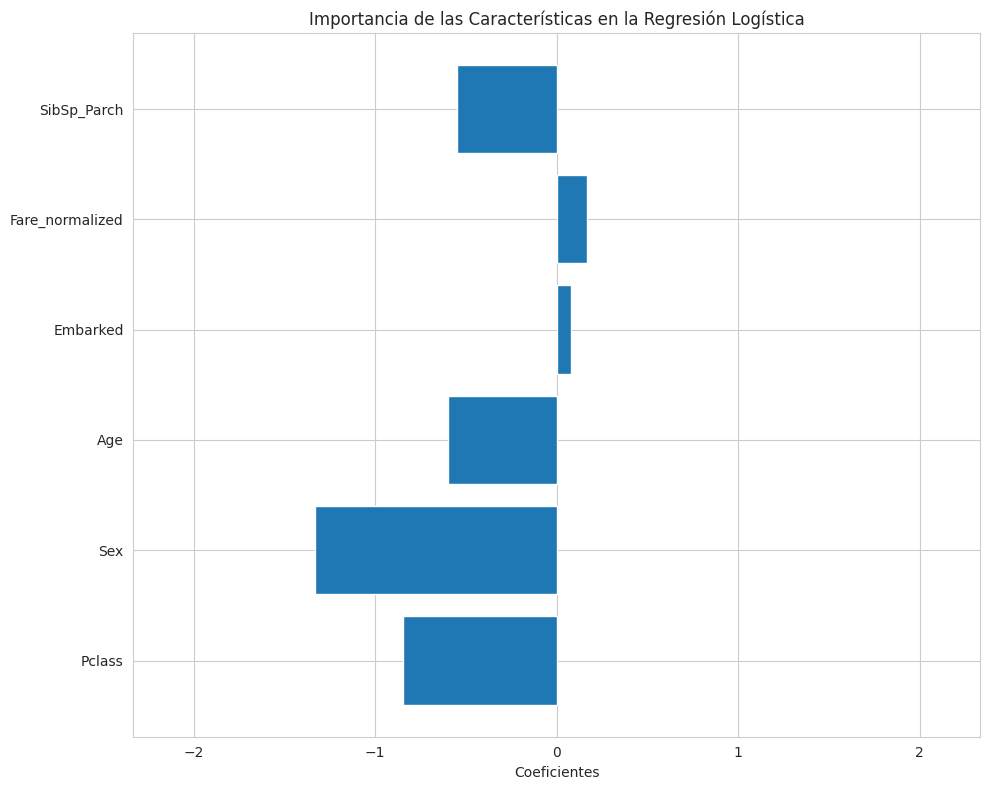

In [14]:
# Realiza predicciones usando el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probabilidades en etiquetas binarias (0 o 1)
y_pred = (y_pred > 0.5)

# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

# Matriz de confusión:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print("confusion matrix: \n", cm)
# gráfica cm
plt.figure(figsize = (8,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction', fontsize = 12)
plt.ylabel('Real', fontsize = 12)
plt.show()

# Exactitud:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("accuracy: ", acc)

# Sensibilidad (recall):
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print("recall: ", recall)

# Precisión:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("precision: ", precision)

# Especificidad
# 'specificity' is just a special case of 'recall'.
# specificity is the recall of the negative class
specificity = recall_score(y_test, y_pred, pos_label=0)
print("specificity: ", specificity)

# Puntuación F1:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("f1 score: ", f1)

# Área bajo la curva:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_pred)
print("auc: ", auc)

# Curva ROC
from sklearn.metrics import roc_curve
plt.figure()
lw = 2
plt.plot(roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange',lw=lw, label='ROC curve (area = %0.2f)' %auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# R Score (R^2 coefficient of determination)
from sklearn.metrics import r2_score
R = r2_score(y_test, y_pred)
print("R2: ", R)

# Visualizar la importancia de las características
feature_names = X.columns # Corrected: Get feature names from X
coefficients = model.coef_
# Configurar el gráfico de barras
fig, ax = plt.subplots(figsize=(10, 8))

# Crear un gráfico de barras horizontal
ax.barh(feature_names, coefficients[0])
ax.set_title('Importancia de las Características en la Regresión Logística')
ax.set_xlabel('Coeficientes')
ax.set_xlim(-max(abs(coefficients[0]))-1, max(abs(coefficients[0]))+1)

plt.tight_layout()
plt.show()

# Guardar el modelo

In [15]:
# Guardar el modelo a un archivo
import joblib
joblib.dump(model, 'logistic_regression_model.pkl')
# Cargar el modelo desde el archivo
loaded_model = joblib.load('logistic_regression_model.pkl')
# Hacer predicciones con el modelo cargado
y_pred = model.predict(X_test)

# ALGORITMO KNN

## IMPORTAR DATOS

              precision    recall  f1-score   support

           0       0.81      0.78      0.80       110
           1       0.67      0.71      0.69        68

    accuracy                           0.75       178
   macro avg       0.74      0.74      0.74       178
weighted avg       0.76      0.75      0.75       178

confusion matrix: 
 [[86 24]
 [20 48]]


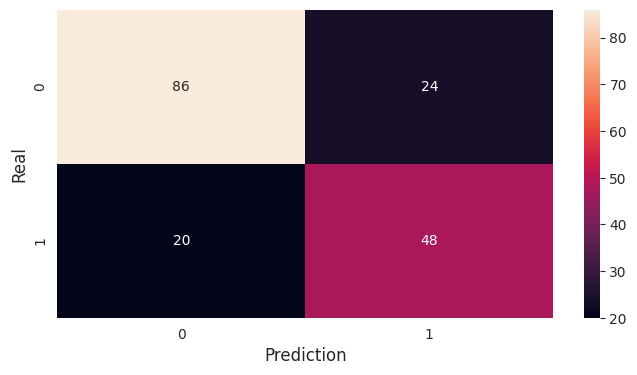

accuracy:  0.7528089887640449
recall:  0.7058823529411765
precision:  0.6666666666666666
specificity:  0.7818181818181819
f1 score:  0.6857142857142857
auc:  0.7438502673796793


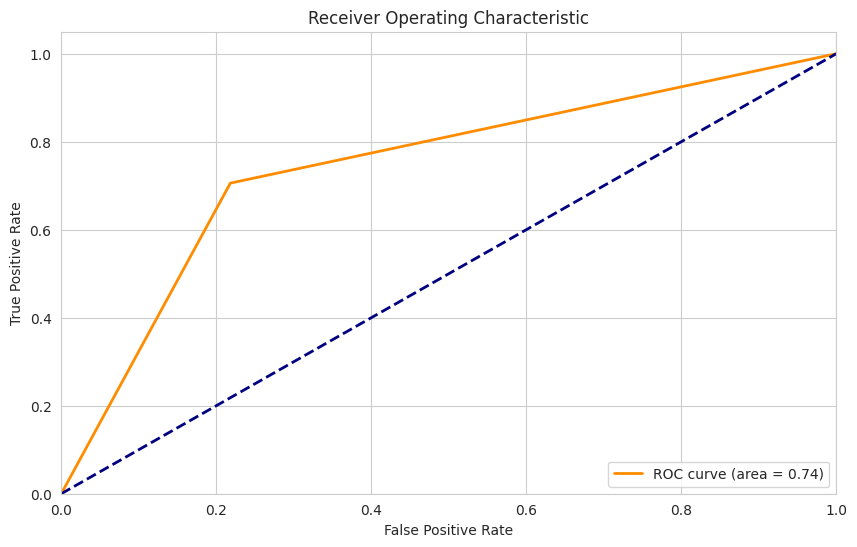

R2:  -0.04705882352941182


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

# Preparación del conjunto de datos Titanic para el modelo
# X contendrá las características (todas las columnas excepto 'Survived')
# y contendrá la variable objetivo ('Survived')
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normaliza los datos para que todas las características tengan una escala similar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # calcula los parámetros: media y desv. estandar
X_test = scaler.transform(X_test) # usa los parámetros (media y desv. estandar) ya calculados en el training set.

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y) # Pass the target variable (y)

# Normaliza los datos para que todas las características tengan una escala similar
scaler = MinMaxScaler(feature_range=(0,1)) # [0, 1]
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Crea y entrena el modelo K-NN
model = KNeighborsClassifier(n_neighbors=3, p=2,  # Función euclidean
                             weights='uniform')

model.fit(X_train, y_train)

# Realiza predicciones usando el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probabilidades en etiquetas binarias (0 o 1)
# y_pred = (y_pred > 0.5)

# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

# Matriz de confusión:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print("confusion matrix: \n", cm)
# gráfica cm
plt.figure(figsize = (8,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction', fontsize = 12)
plt.ylabel('Real', fontsize = 12)
plt.show()

# Exactitud:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("accuracy: ", acc)

# Sensibilidad:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print("recall: ", recall)

# Precisión:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("precision: ", precision)

# Especificidad
# 'specificity' is just a special case of 'recall'.
# specificity is the recall of the negative class
specificity = recall_score(y_test, y_pred, pos_label=0)
print("specificity: ", specificity)

# Puntuación F1:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("f1 score: ", f1)

# Área bajo la curva:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_pred)
print("auc: ", auc)

# Curva ROC
from sklearn.metrics import roc_curve
plt.figure()
lw = 2
plt.plot(roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange',lw=lw, label='ROC curve (area = %0.2f)' %auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# R Score (R^2 coefficient of determination)
from sklearn.metrics import r2_score
R = r2_score(y_test, y_pred)
print("R2: ", R)

# Guardar el modelo a un archivo
import joblib
joblib.dump(model, 'knn_model.pkl')
# Cargar el modelo desde el archivo
loaded_model = joblib.load('knn_model.pkl')
# Hacer predicciones con el modelo cargado
y_pred = model.predict(X_test)


# # SHAP (SHapley Additive exPlanations) para explicar las predicciones de un modelo de machine learning.
# import shap # pip install shap
# # La combinación de K-NN y KernelExplainer es inherentemente lenta debido a la naturaleza computacional de ambos.
# # Por lo que se puede usar una muestra más pequeña de los datos para obtener una idea aproximada de las explicaciones.
# sample_size = 50  # ajustar según sea necesario
# X_train_sample = shap.sample(X_train, sample_size)
# X_test_sample = shap.sample(X_test, sample_size)
# # Crear un explainer de SHAP usando en conjunto de entrenamiento
# explainer = shap.KernelExplainer(model.predict_proba, X_train_sample)
# # Obtener las explicaciones SHAP para el conjunto de prueba
# shap_values = explainer.shap_values(X_test_sample)
# # Proporciona una visión general de la importancia de las características y su impacto en las predicciones.
# shap.summary_plot(shap_values[1], X_test_sample, feature_names=dataset.feature_names)

---
## Conclusiones Generales

1. El dataset no presenta valores perdidos, lo cual facilita el análisis sin necesidad de imputación.
2. Existe un ligero desbalance entre las clases benigno y maligno, que debe considerarse al entrenar modelos predictivos.
3. Las variables más relevantes para la predicción son las relacionadas con el tamaño del tumor (radius, perimeter, area) y la concavidad de sus bordes.
4. Se detectó alta multicolinealidad entre variables de tamaño, lo que sugiere que podría aplicarse reducción de dimensionalidad o selección de características.
5. La normalización de los datos se realizó con MinMaxScaler, ajustando los valores al rango [0, 1], lo cual es importante para algoritmos sensibles a la escala de las variables.
6. El desarrollo de la práctica permitió aplicar correctamente las etapas de preprocesamiento y análisis exploratorio de datos utilizando Python y sus librerías especializadas. A través de las estadísticas descriptivas y visualizaciones se logró comprender mejor el comportamiento del dataset y la relación entre las variables analizadas.
7. El análisis realizado permitió identificar variables relevantes asociadas al diagnóstico, además de evidenciar la importancia de la limpieza, transformación y exploración de datos como parte fundamental de cualquier proyecto.


---
## Aplicación en campo profesional
1. **Santiago Calle:** Como ingeniero mecatrónico los conocimientos que adquirí en esta práctica junto con los temas revisados durante la semana pueden aplicarse en mi entorno laboral para analizar información generada por máquinas, sensores y procesos automatizados.
En mi trabajo, estos conocimientos pueden utilizarse para detectar comportamientos anormales en equipos, analizar tendencias de temperatura, corriente, presión o tiempos de operación y así mejorar el mantenimiento preventivo y la eficiencia de los sistemas. También permiten organizar y limpiar datos antes de analizarlos, evitando errores y obteniendo información más confiable para la toma de decisiones.
Con el análisis exploratorio me permite tener entre variables estadísticas y gráficos, facilitando la interpretación del comportamiento de los procesos industriales y apoyando futuras implementaciones de modelos predictivos.

2. **Alexander Luna:** Al igual que con el dataset de cáncer, donde buscamos patrones celulares anómalos para detectar un tumor maligno antes de que sea tarde, en el Registro de La Propiedad podemos entrenar un modelo con el histórico de transacciones para detectar patrones inusuales en las solicitudes de inscripción (ej. cambios bruscos de propietario, horas inusuales de ingreso, o solicitudes sobre bienes con litigios). Aquí optimizaríamos el Recall para asegurar que el sistema detecte cualquier posible irregularidad antes de que pase a la firma del Registrador o Jerárquico Superior.

3. **Alvaro Quisilema:** Como ingeniero mecatrónico especializado en sistemas de seguridad y control de asistencia, este tipo de análisis de datos es directamente aplicable a mi campo profesional. Por ejemplo, puedo utilizar la misma metodología para analizar datos de sensores en dispositivos de control de acceso ( biométricos, torniquetes, cámaras) y predecir fallos antes de que ocurran, identificando qué variables como temperatura, tiempo de respuesta o voltaje son las más relevantes. De igual forma, en el área de control de asistencia, este enfoque me permite detectar patrones de ausentismo o anomalías en los registros de marcación, facilitando una gestión más eficiente y basada en datos.


#Semana 3

# Decision Tree

### Preparación de datos para el Árbol de Decisión

Primero, preparamos el conjunto de datos para el entrenamiento del modelo de Árbol de Decisión. Esto incluye dividir los datos en conjuntos de entrenamiento y prueba, y escalar las características para que tengan una escala similar, lo que es importante para algunos algoritmos.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Carga el conjunto de datos (X = características, y = variable objetivo)
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y) # Usamos stratify para mantener la proporción de clases

# Normaliza los datos usando MinMaxScaler para que todas las características estén en el rango [0, 1]
scaler = MinMaxScaler(feature_range=(0,1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos preparados para el modelo de Árbol de Decisión.")

Datos preparados para el modelo de Árbol de Decisión.


### Entrenamiento del modelo de Árbol de Decisión

Aquí, inicializamos y entrenamos el `DecisionTreeClassifier` con parámetros específicos como la profundidad máxima del árbol (`max_depth`) y el criterio de división (`criterion`).

In [18]:
from sklearn.tree import DecisionTreeClassifier

# Crea y entrena el modelo de árbol de decisión
model = DecisionTreeClassifier(max_depth=4, criterion = 'gini')
model.fit(X_train, y_train)

print("Modelo de Árbol de Decisión entrenado exitosamente.")

Modelo de Árbol de Decisión entrenado exitosamente.


### Evaluación del modelo: Métricas de rendimiento

Evaluamos el rendimiento del modelo utilizando varias métricas de clasificación, como el `classification_report`, la `confusion_matrix`, `accuracy`, `recall`, `precision`, `f1_score`, `specificity`, `auc` y `r2_score`.

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Realiza predicciones usando el conjunto de prueba
y_pred = model.predict(X_test)

# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

# Matriz de confusión:
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix: \n", cm)

# Exactitud:
acc = accuracy_score(y_test, y_pred)
print("accuracy: ", acc)

# Sensibilidad:
recall = recall_score(y_test, y_pred)
print("recall: ", recall)

# Precisión:
precision = precision_score(y_test, y_pred)
print("precision: ", precision)

# Especificidad (recall de la clase negativa)
specificity = recall_score(y_test, y_pred, pos_label=0)
print("specificity: ", specificity)

# Puntuación F1:
f1 = f1_score(y_test, y_pred)
print("f1 score: ", f1)

# Área bajo la curva:
auc = roc_auc_score(y_test, y_pred)
print("auc: ", auc)

# R Score (R^2 coefficient of determination)
R = r2_score(y_test, y_pred)
print("R2: ", R)

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.80      0.66      0.73        68

    accuracy                           0.81       178
   macro avg       0.81      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178

confusion matrix: 
 [[99 11]
 [23 45]]
accuracy:  0.8089887640449438
recall:  0.6617647058823529
precision:  0.8035714285714286
specificity:  0.9
f1 score:  0.7258064516129032
auc:  0.7808823529411765
R2:  0.19090909090909092


### Visualización de la Matriz de Confusión

La matriz de confusión nos permite visualizar el rendimiento del algoritmo, mostrando el número de predicciones correctas e incorrectas para cada clase.

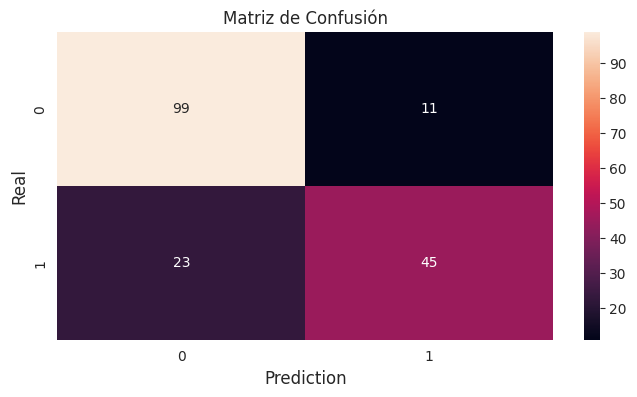

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# gráfica cm
plt.figure(figsize = (8,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction', fontsize = 12)
plt.ylabel('Real', fontsize = 12)
plt.title('Matriz de Confusión')
plt.show()

### Curva ROC

La curva ROC (Receiver Operating Characteristic) ilustra la capacidad de diagnóstico de un clasificador binario a medida que su umbral de discriminación varía. El AUC (Area Under the Curve) representa el grado o la medida de la separabilidad.

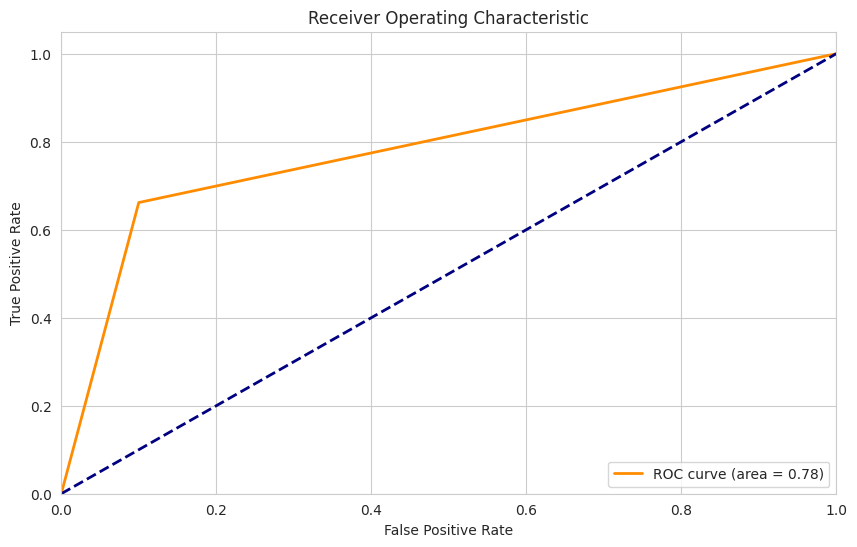

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure()
lw = 2
plt.plot(roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange',lw=lw, label='ROC curve (area = %0.2f)' %auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Visualización del Árbol de Decisión

Visualizar el árbol de decisión nos ayuda a entender cómo el modelo toma decisiones basándose en las características de entrada.

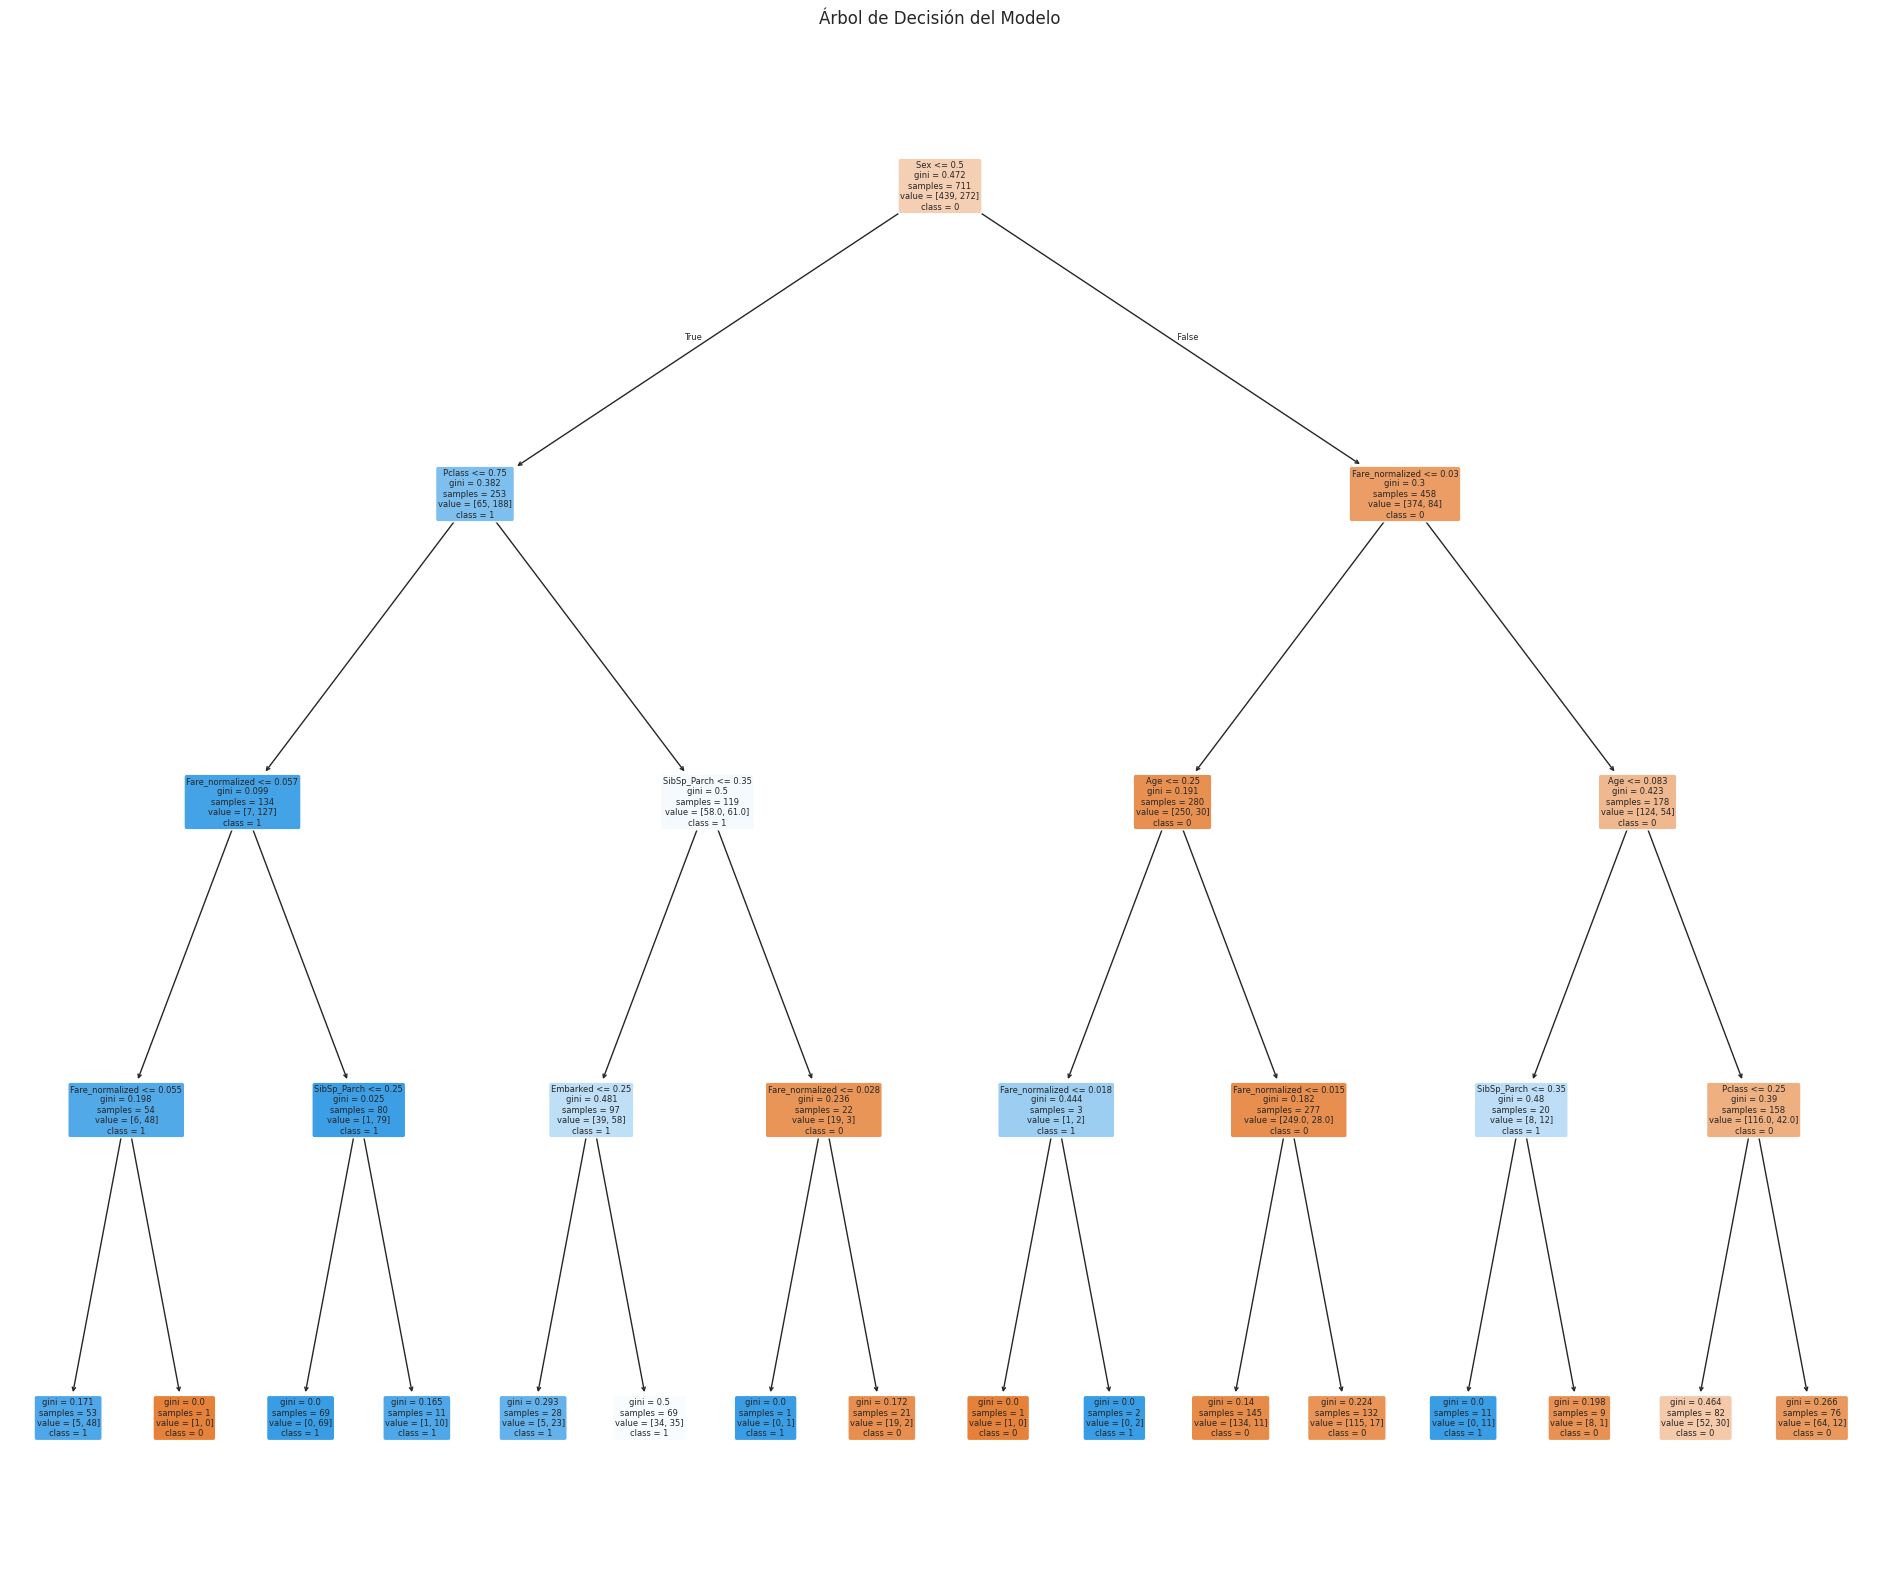

In [22]:
from sklearn.tree import plot_tree

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(24, 20))

# Dibujar el árbol de decisión
plot_tree(model,
                feature_names = X.columns.tolist(),
                class_names = y.unique().astype(str).tolist(),
                filled=True,
                rounded=True,
                ax=ax)

# Mostrar la gráfica
plt.title('Árbol de Decisión del Modelo')
plt.show()

### Importancia de las Características

La importancia de las características indica cuánto contribuye cada variable a la predicción del modelo. Un valor más alto significa que la característica es más relevante.

          Variable  Importancia
1              Sex     0.605220
0           Pclass     0.161719
5      SibSp_Parch     0.092593
4  Fare_normalized     0.082400
2              Age     0.034759
3         Embarked     0.023309


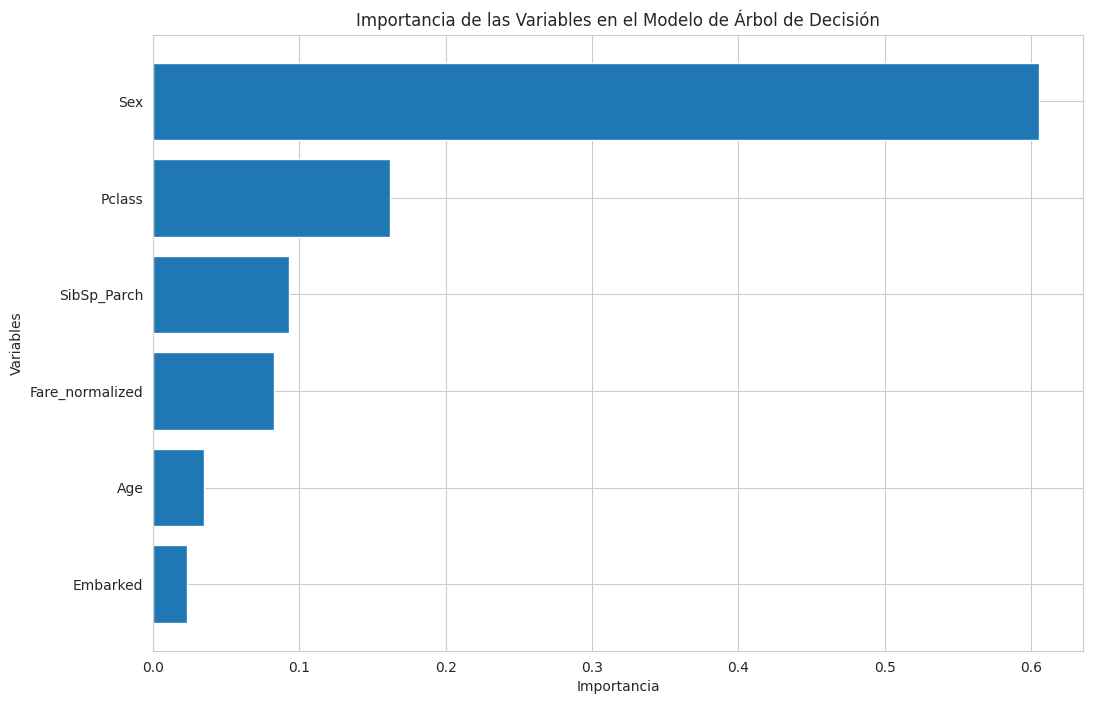

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Calcular y visualizar la importancia de las variables en la predicción del modelo
importances = model.feature_importances_

# Crear un DataFrame para visualizar las importancias
feature_importances = pd.DataFrame({
    'Variable': X.columns.tolist(),
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

print(feature_importances)

# Visualizar las importancias de las variables
plt.figure(figsize=(12, 8))
plt.barh(feature_importances['Variable'], feature_importances['Importancia'])
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.title('Importancia de las Variables en el Modelo de Árbol de Decisión')
plt.gca().invert_yaxis()
plt.show()

### Guardar y Cargar el Modelo

Es una buena práctica guardar los modelos entrenados para poder reutilizarlos sin necesidad de reentrenarlos. Esto se hace comúnmente usando la librería `joblib`.

In [24]:
import joblib

# Guardar el modelo a un archivo
joblib.dump(model, 'decision_tree_model.pkl')
print("Modelo guardado como 'decision_tree_model.pkl'")

# Cargar el modelo desde el archivo
loaded_model = joblib.load('decision_tree_model.pkl')
print("Modelo cargado desde 'decision_tree_model.pkl'")

# Hacer predicciones con el modelo cargado (demostración)
y_pred_loaded = loaded_model.predict(X_test)
print("Predicciones realizadas con el modelo cargado.")

Modelo guardado como 'decision_tree_model.pkl'
Modelo cargado desde 'decision_tree_model.pkl'
Predicciones realizadas con el modelo cargado.


### Análisis SHAP

SHAP (SHapley Additive exPlanations) es una técnica para explicar las predicciones de un modelo de machine learning, mostrando cómo cada característica contribuye a la predicción.

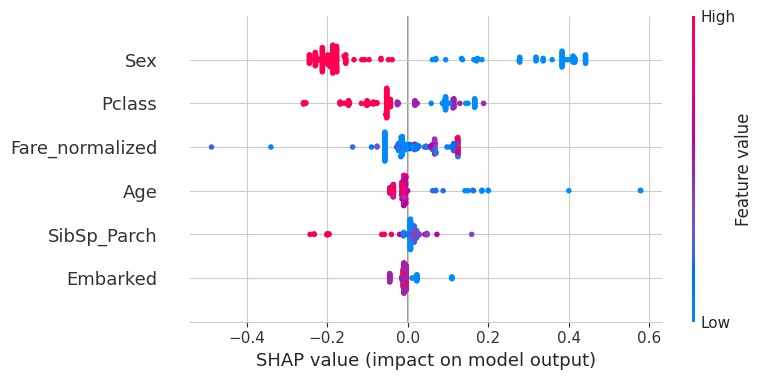

In [25]:
import shap # pip install shap
import pandas as pd # Import pandas

# Crear un explainer de SHAP usando en conjunto de entrenamiento
explainer = shap.TreeExplainer(model)

# Obtener las explicaciones SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test)

# Convert X_test (which is a numpy array) back to a DataFrame with feature names
# This ensures that shap.summary_plot can correctly interpret the features
X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())

# Proporciona una visión general de la importancia de las características y su impacto en las predicciones.
# For a 3D shap_values array (samples, features, classes), shap_values[:, :, 1] extracts the values for class 1
shap.summary_plot(shap_values[:, :, 1], X_test_df, feature_names=X.columns.tolist())

## Radom Forest

### Preparación de datos para Random Forest

Preparamos el conjunto de datos para el entrenamiento del modelo Random Forest. Esto incluye dividir los datos en conjuntos de entrenamiento y prueba, y escalar las características para que tengan una escala similar, lo que puede ayudar a algunos algoritmos a converger más rápido o a rendir mejor.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Carga el conjunto de datos (X = características, y = variable objetivo)
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y) # Usamos stratify para mantener la proporción de clases

# Normaliza los datos usando MinMaxScaler para que todas las características estén en el rango [0, 1]
scaler = MinMaxScaler(feature_range=(0,1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos preparados para el modelo Random Forest.")

Datos preparados para el modelo Random Forest.


### Entrenamiento del modelo Random Forest

Aquí, inicializamos y entrenamos el `RandomForestClassifier` con parámetros específicos como el número de estimadores (`n_estimators`), la profundidad máxima de los árboles (`max_depth`) y el criterio de división (`criterion`).

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Crea y entrena el modelo Random Forest
model = RandomForestClassifier(n_estimators=10, max_depth=4, criterion='entropy', random_state=42)
model.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

Modelo Random Forest entrenado exitosamente.


### Evaluación del modelo: Métricas de rendimiento

Evaluamos el rendimiento del modelo utilizando varias métricas de clasificación, como el `classification_report`, la `confusion_matrix`, `accuracy`, `recall`, `precision`, `f1_score`, `specificity`, `auc` y `r2_score`.

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Realiza predicciones usando el conjunto de prueba
y_pred = model.predict(X_test)

# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

# Matriz de confusión:
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix: \n", cm)

# Exactitud:
acc = accuracy_score(y_test, y_pred)
print("accuracy: ", acc)

# Sensibilidad:
recall = recall_score(y_test, y_pred)
print("recall: ", recall)

# Precisión:
precision = precision_score(y_test, y_pred)
print("precision:C ", precision)

# Especificidad (recall de la clase negativa)
specificity = recall_score(y_test, y_pred, pos_label=0)
print("specificity: ", specificity)

# Puntuación F1:
f1 = f1_score(y_test, y_pred)
print("f1 score: ", f1)

# Área bajo la curva:
auc = roc_auc_score(y_test, y_pred)
print("auc: ", auc)

# R Score (R^2 coefficient of determination)
R = r2_score(y_test, y_pred)
print("R2: ", R)

              precision    recall  f1-score   support

           0       0.79      0.91      0.84       110
           1       0.80      0.60      0.69        68

    accuracy                           0.79       178
   macro avg       0.80      0.76      0.77       178
weighted avg       0.79      0.79      0.78       178

confusion matrix: 
 [[100  10]
 [ 27  41]]
accuracy:  0.7921348314606742
recall:  0.6029411764705882
precision:C  0.803921568627451
specificity:  0.9090909090909091
f1 score:  0.6890756302521008
auc:  0.7560160427807487
R2:  0.1195187165775401


### Visualización de la Matriz de Confusión

La matriz de confusión nos permite visualizar el rendimiento del algoritmo, mostrando el número de predicciones correctas e incorrectas para cada clase.

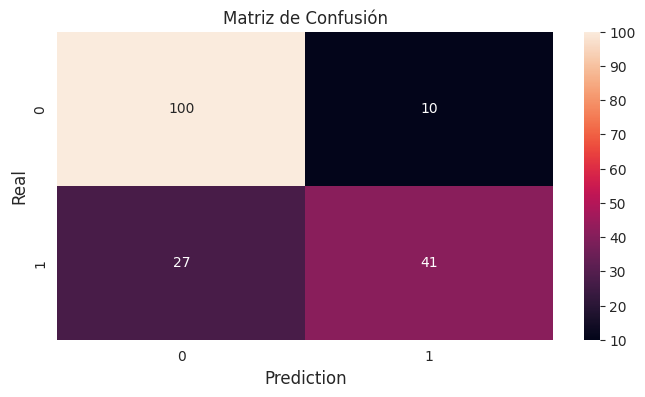

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# gráfica cm
plt.figure(figsize = (8,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction', fontsize = 12)
plt.ylabel('Real', fontsize = 12)
plt.title('Matriz de Confusión')
plt.show()

### Curva ROC

La curva ROC (Receiver Operating Characteristic) ilustra la capacidad de diagnóstico de un clasificador binario a medida que su umbral de discriminación varía. El AUC (Area Under the Curve) representa el grado o la medida de la separabilidad, es decir, cuánto es capaz el modelo de distinguir entre clases.

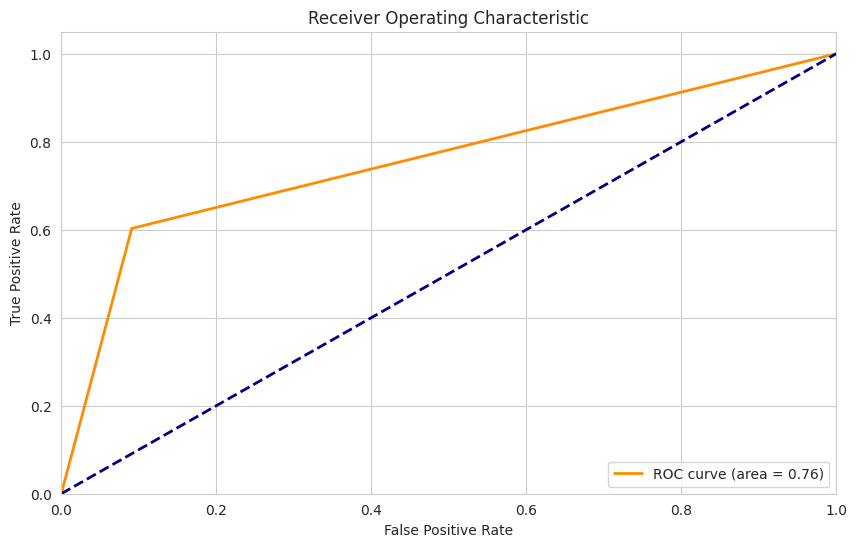

In [30]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure()
lw = 2
plt.plot(roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange',lw=lw, label='ROC curve (area = %0.2f)' %auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Visualización de un Árbol de Decisión Individual

Un Random Forest se compone de múltiples árboles de decisión. Visualizar uno de ellos puede ayudar a entender cómo el modelo toma decisiones, aunque la complejidad del bosque completo hace que esta visualización sea más ilustrativa que explicativa para el modelo general.

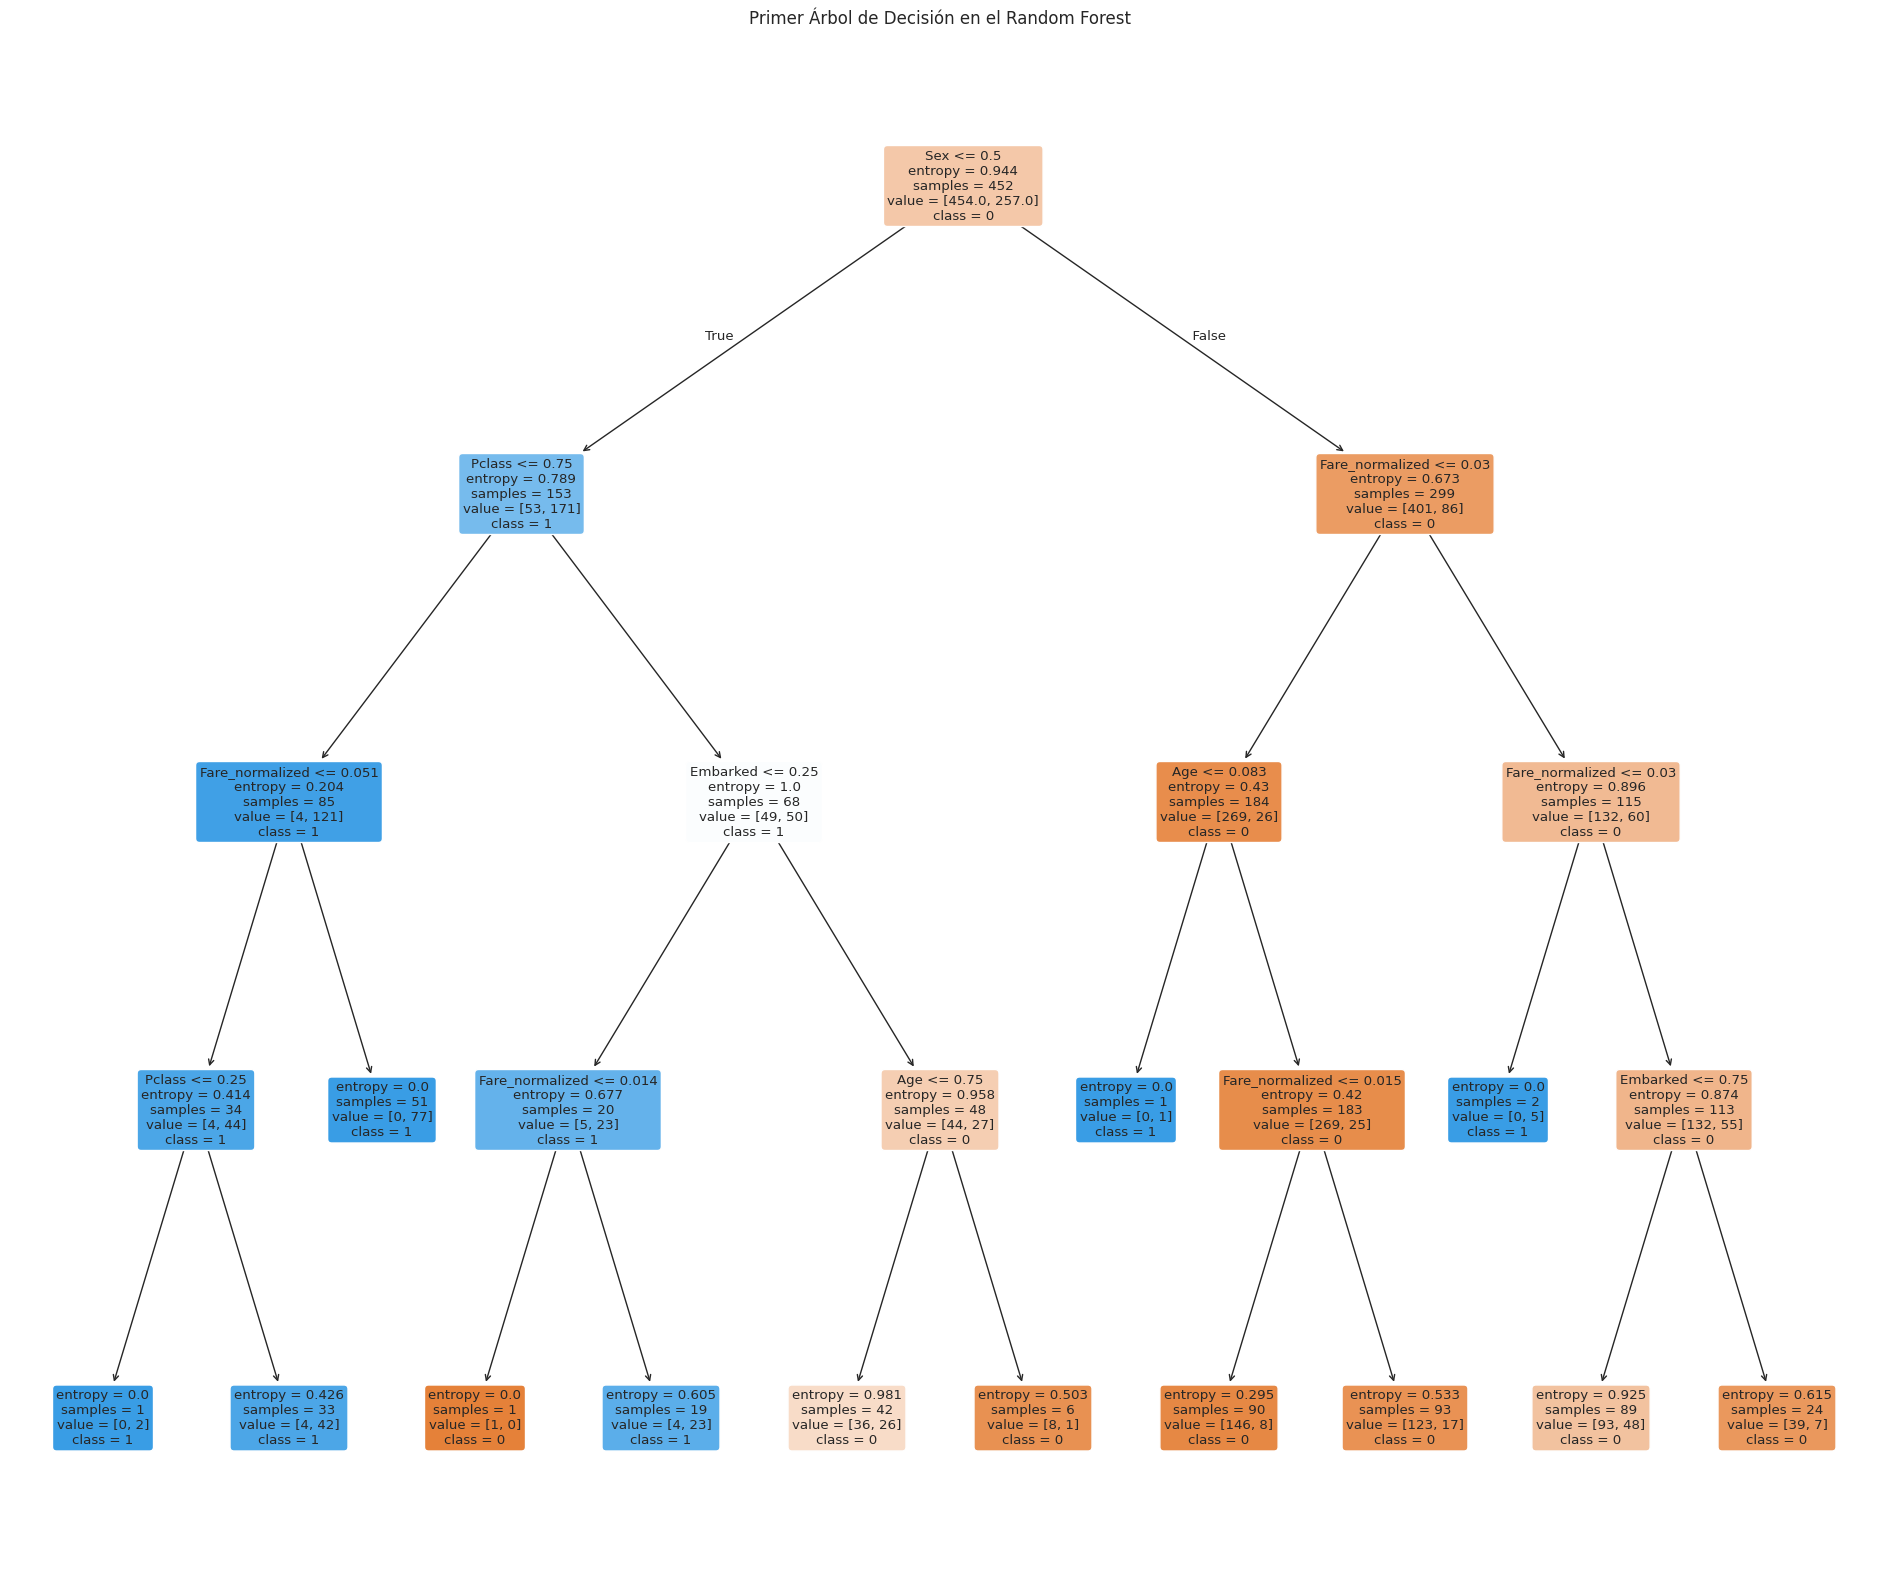

In [31]:
from sklearn.tree import plot_tree

# Seleccionar el primer árbol (0) del modelo Random Forest para visualizar.
# Visualizar el bosque completo no es práctico por la gran cantidad de árboles.
estimator = model.estimators_[0]

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(24, 20))

# Dibujar el árbol de decisión
plot_tree(estimator,
                feature_names = X.columns.tolist(),
                class_names = y.unique().astype(str).tolist(),
                filled=True,
                rounded=True,
                ax=ax)

# Mostrar la gráfica
plt.title('Primer Árbol de Decisión en el Random Forest')
plt.show()

### Importancia de las Características

La importancia de las características indica cuánto contribuye cada variable a la predicción del modelo. Un valor más alto significa que la característica es más relevante.

          Variable  Importancia
1              Sex     0.385792
4  Fare_normalized     0.277935
0           Pclass     0.128183
5      SibSp_Parch     0.096094
3         Embarked     0.061685
2              Age     0.050312


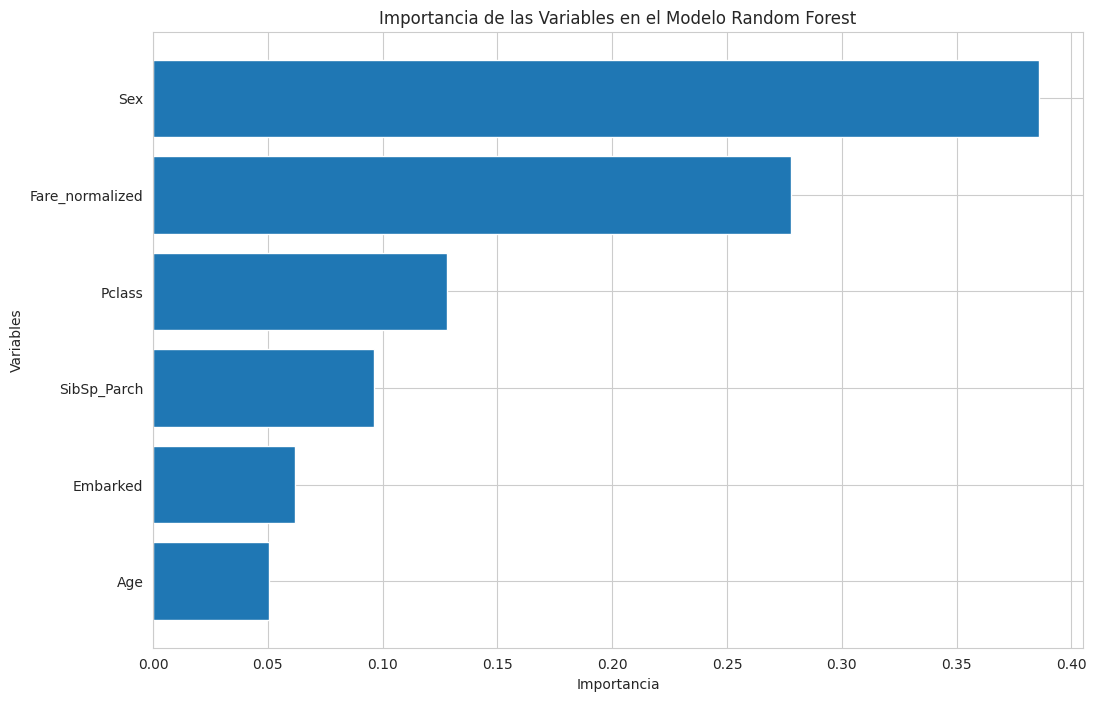

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Calcular y visualizar la importancia de las variables en la predicción del modelo
importances = model.feature_importances_

# Crear un DataFrame para visualizar las importancias
feature_importances = pd.DataFrame({
    'Variable': X.columns.tolist(),
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

print(feature_importances)

# Visualizar las importancias de las variables
plt.figure(figsize=(12, 8))
plt.barh(feature_importances['Variable'], feature_importances['Importancia'])
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.title('Importancia de las Variables en el Modelo Random Forest')
plt.gca().invert_yaxis()
plt.show()

### Guardar y Cargar el Modelo

Es una buena práctica guardar los modelos entrenados para poder reutilizarlos sin necesidad de reentrenarlos. Esto se hace comúnmente usando la librería `joblib`.

In [33]:
import joblib

# Guardar el modelo a un archivo
joblib.dump(model, 'random_forest_model.pkl')
print("Modelo guardado como 'random_forest_model.pkl'")

# Cargar el modelo desde el archivo
loaded_model = joblib.load('random_forest_model.pkl')
print("Modelo cargado desde 'random_forest_model.pkl'")

# Hacer predicciones con el modelo cargado (demostración)
y_pred_loaded = loaded_model.predict(X_test)
print("Predicciones realizadas con el modelo cargado.")

Modelo guardado como 'random_forest_model.pkl'
Modelo cargado desde 'random_forest_model.pkl'
Predicciones realizadas con el modelo cargado.


# Red Neuronal

### Preparación de Datos para la Red Neuronal

Preparamos el conjunto de datos para el entrenamiento de la Red Neuronal. Esto implica dividir los datos en conjuntos de entrenamiento y prueba, y luego normalizar las características utilizando `MinMaxScaler` para asegurar que estén en un rango consistente, lo cual es crucial para el buen rendimiento de las redes neuronales.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Carga el conjunto de datos (X = características, y = variable objetivo)
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y) # Usamos stratify para mantener la proporción de clases

# Normaliza los datos usando MinMaxScaler para que todas las características estén en el rango [0, 1]
scaler = MinMaxScaler(feature_range=(0,1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos preparados para el modelo de Red Neuronal.")

Datos preparados para el modelo de Red Neuronal.


### Definición y Compilación del Modelo de Red Neuronal

En esta sección, definimos la arquitectura de la Red Neuronal utilizando Keras `Sequential` API. Incluimos capas densas con activación ReLU y una capa de salida con activación sigmoide para la clasificación binaria. También se añade una capa `Dropout` para ayudar a prevenir el sobreajuste. Luego, compilamos el modelo especificando la función de pérdida, el optimizador y las métricas a monitorear durante el entrenamiento.

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Crea el modelo Sequential
model = Sequential()
# Añade la primera capa densa con el número de características de entrada
model.add(Dense(10, activation='relu', input_dim=X_train.shape[1]))
# Añade una capa Dropout para regularización
model.add(Dropout(0.2))
# Añade la capa de salida para clasificación binaria
model.add(Dense(1, activation='sigmoid'))

# Muestra un resumen de la arquitectura del modelo
model.summary()

# Define el optimizador Adam con una tasa de aprendizaje específica
opt = Adam(learning_rate = 1e-2)
# Compila el modelo
model.compile(loss='binary_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del Modelo de Red Neuronal

Aquí entrenamos la Red Neuronal utilizando los datos de entrenamiento (`X_train`, `y_train`) y validamos su rendimiento con los datos de prueba (`X_test`, `y_test`). Configuramos `EarlyStopping` para detener el entrenamiento si el rendimiento en el conjunto de validación no mejora, lo que ayuda a evitar el sobreajuste y a obtener el mejor modelo.

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

# Configurar early stopping para evitar overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10,
                               restore_best_weights=True)

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1,
          validation_data=(X_test, y_test), callbacks=[early_stopping])

print("Modelo de Red Neuronal entrenado exitosamente.")

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5851 - loss: 0.6638 - val_accuracy: 0.6180 - val_loss: 0.6179
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6596 - loss: 0.6040 - val_accuracy: 0.6685 - val_loss: 0.5808
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7328 - loss: 0.5595 - val_accuracy: 0.7809 - val_loss: 0.5440
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7370 - loss: 0.5456 - val_accuracy: 0.7809 - val_loss: 0.5139
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7454 - loss: 0.5341 - val_accuracy: 0.7753 - val_loss: 0.4968
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7722 - loss: 0.5143 - val_accuracy: 0.7865 - val_loss: 0.4827
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7778 - loss: 0.5040 - val_accuracy: 0.8034 - val_loss: 0.4715
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7609 - loss: 0.5017 - val_accuracy: 0.

### Evaluación del Modelo: Métricas de Rendimiento

Evaluamos el rendimiento del modelo de Red Neuronal utilizando diversas métricas de clasificación, incluyendo el informe de clasificación, la matriz de confusión, la exactitud (accuracy), la sensibilidad (recall), la precisión, la especificidad, la puntuación F1, y el área bajo la curva (AUC). También se calcula el R2 score para tener una visión más completa del rendimiento.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       110
           1       0.83      0.63      0.72        68

    accuracy                           0.81       178
   macro avg       0.81      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178

confusion matrix: 
 [[101   9]
 [ 25  43]]


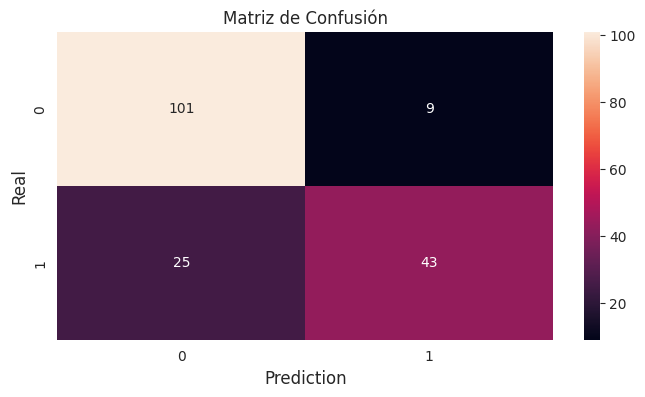

accuracy:  0.8089887640449438
recall:  0.6323529411764706
precision:  0.8269230769230769
specificity:  0.9181818181818182
f1 score:  0.7166666666666667
auc:  0.7752673796791444


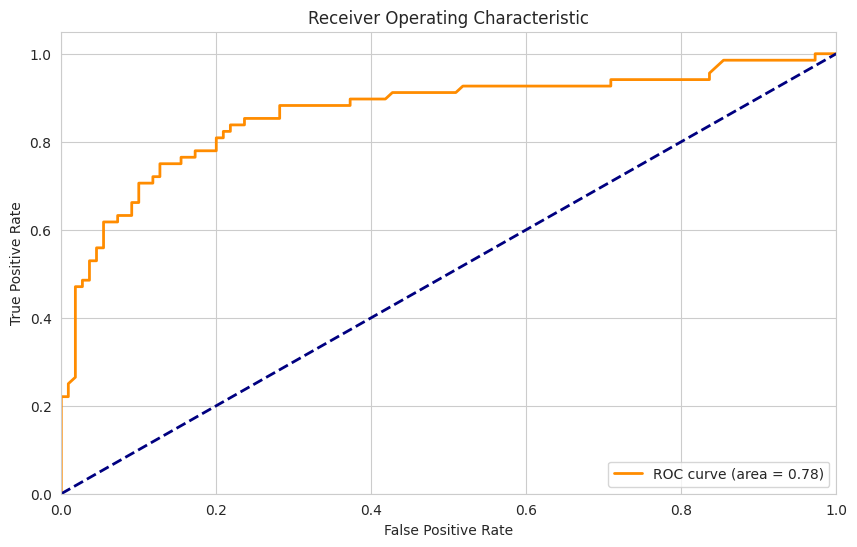

R2:  0.19090909090909092


In [37]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Realiza predicciones usando el conjunto de prueba
y_pred_proba = model.predict(X_test)
# Convierte las salidas en etiquetas binarias (0 o 1)
y_pred = (y_pred_proba > 0.5)

# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

# Matriz de confusión:
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix: \n", cm)
# gráfica cm
plt.figure(figsize = (8,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction', fontsize = 12)
plt.ylabel('Real', fontsize = 12)
plt.title('Matriz de Confusión')
plt.show()

# Exactitud:
acc = accuracy_score(y_test, y_pred)
print("accuracy: ", acc)

# Sensibilidad:
recall = recall_score(y_test, y_pred)
print("recall: ", recall)

# Precisión:
precision = precision_score(y_test, y_pred)
print("precision: ", precision)

# Especificidad
specificity = recall_score(y_test, y_pred, pos_label=0)
print("specificity: ", specificity)

# Puntuación F1:
f1 = f1_score(y_test, y_pred)
print("f1 score: ", f1)

# Área bajo la curva:
auc = roc_auc_score(y_test, y_pred)
print("auc: ", auc)

# Curva ROC
plt.figure()
lw = 2
plt.plot(roc_curve(y_test, y_pred_proba)[0], roc_curve(y_test, y_pred_proba)[1], color='darkorange',lw=lw, label='ROC curve (area = %0.2f)' %auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# R Score (R^2 coefficient of determination)
R = r2_score(y_test, y_pred)
print("R2: ", R)

### Curvas de Aprendizaje

Visualizamos las curvas de pérdida y exactitud durante el entrenamiento y la validación. Esto nos permite observar el progreso del modelo y detectar posibles problemas como el sobreajuste o el subajuste.

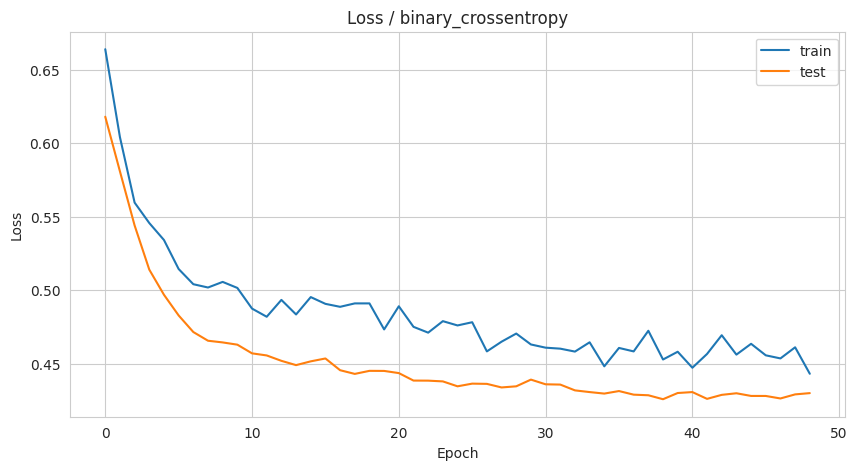

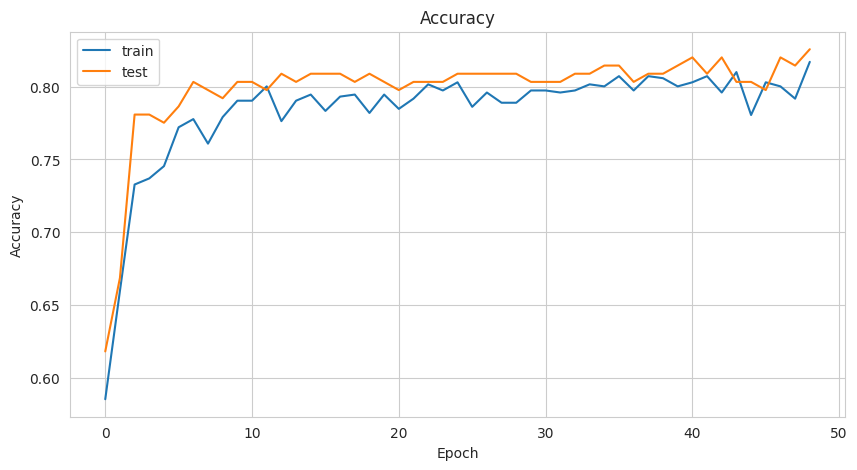

In [38]:
import matplotlib.pyplot as plt

# plot loss during training
plt.figure(figsize=(10, 5))
plt.title('Loss / binary_crossentropy')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# plot accuracy during training
plt.figure(figsize=(10, 5))
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Guardar y Cargar el Modelo de Red Neuronal

Guardamos el modelo entrenado en un archivo `.h5` para poder reutilizarlo más tarde sin necesidad de volver a entrenarlo. También demostramos cómo cargar el modelo desde este archivo.

In [39]:
from tensorflow.keras.models import load_model

# Guardar el modelo completo (arquitectura, pesos, bias y configuración) en un archivo HDF5
model.save('RNA_model.h5')
print("Modelo guardado.")

# Cargar el modelo desde el archivo HDF5
loaded_model = load_model('RNA_model.h5')
print("Modelo cargado.")

Modelo guardado.
Modelo cargado.


### Análisis SHAP

El análisis SHAP es una herramienta poderosa para explicar las predicciones de un modelo. Permite entender cómo cada característica contribuye a la salida del modelo.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(711, 6))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1422, 6))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(178, 6))']
  warnings.warn(msg)

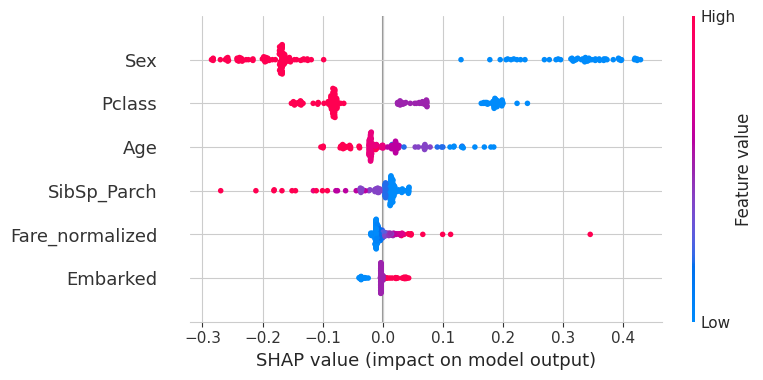

In [40]:
import shap # pip install shap
import numpy as np # Import numpy for array manipulation
import pandas as pd # Import pandas for DataFrame creation

# Para redes neuronales, a menudo se usa DeepExplainer o KernelExplainer.
# DeepExplainer es más rápido pero requiere tensores de entrada específicos y es para modelos Keras/TensorFlow.
# KernelExplainer es más general pero más lento.

# Si tu modelo de Keras tiene tensores como entrada, DeepExplainer es la opción más eficiente.
# Se inicializa DeepExplainer con el modelo y el conjunto de datos de entrenamiento como 'background'.
explainer = shap.DeepExplainer(model, X_train)

# # Para un enfoque más general, o si DeepExplainer tiene problemas con tu setup (este bloque está comentado):
# # Hay que tener en cuenta que KernelExplainer es computacionalmente intensivo para conjuntos de datos grandes.
# # Se puede usar una muestra del conjunto de entrenamiento para la base del explainer.
# # background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)] # Muestra de 100 elementos
# # explainer = shap.KernelExplainer(model.predict, background)

# Obtener las explicaciones SHAP para el conjunto de prueba
shap_values = explainer.shap_values(X_test)

# DeepExplainer para modelos con una única salida (como clasificación binaria con sigmoid)
# a menudo devuelve shap_values como una lista de dos arrays (uno para cada clase) o
# un array 3D de forma (samples, features, 1). Necesitamos asegurar que sea 2D (samples, features).
# Si shap_values es una lista, toma el segundo elemento (clase 1). Si es un array 3D, aplana la última dimensión.
if isinstance(shap_values, list):
    # Si es una lista, asumimos que son [shap_values_class0, shap_values_class1]
    shap_values_to_plot = shap_values[1] # Selecciona los SHAP values para la clase positiva
elif shap_values.ndim == 3 and shap_values.shape[2] == 1:
    # Si es un array 3D (samples, features, 1), elimina la última dimensión
    shap_values_to_plot = shap_values.squeeze()
else:
    # Si no es ninguna de las anteriores, asumimos que ya es 2D
    shap_values_to_plot = shap_values

# Asegurarse de tener feature_names si se va a usar summary_plot
feature_names = X.columns.tolist()

# Convertir X_test (que es un array de numpy) a un DataFrame con los nombres de las características.
# Esto es crucial para que shap.summary_plot muestre los nombres correctos en el eje.
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Proporciona una visión general de la importancia de las características y su impacto en las predicciones.
# Generalmente, se visualizan los SHAP values de la clase positiva (clase 1).
shap.summary_plot(shap_values_to_plot, X_test_df, feature_names=feature_names)

## Conclusiones

1.  **Preprocesamiento de Datos:** Los pasos de preprocesamiento, como la codificación de variables categóricas (`Sex`, `Embarked`), el manejo de valores faltantes (imputación de `Age`, eliminación de `Cabin`), la creación de la característica `SibSp_Parch` y la normalización con `MinMaxScaler`, fueron fundamentales y consistentes para preparar los datos para todos los modelos. Esto aseguró que las características tuvieran una escala similar, beneficiando el rendimiento del modelo.

2.  **Rendimiento General de los Modelos:** Los modelos de Árbol de Decisión, Random Forest y Red Neuronal Artificial mostraron un rendimiento comparable en la tarea de predicción de supervivencia en el dataset del Titanic, con métricas de `accuracy` alrededor del 80-81%. La `matriz de confusión` y las `curvas ROC` confirmaron su capacidad para clasificar la supervivencia.

3.  **Importancia de las Características:** Consistentemente, la variable `Sex` (género) emergió como la característica más influyente para la predicción de supervivencia en todos los modelos. `Pclass` (clase del pasajero) y `Fare_normalized` (tarifa normalizada) también mostraron una importancia significativa, indicando que el estatus socioeconómico y el género fueron factores clave en la supervivencia del Titanic. Otras variables como `SibSp_Parch` y `Age` también contribuyeron, aunque en menor medida.

4.  **Interpretación del Modelo con SHAP:** El análisis SHAP, aplicado a la Red Neuronal, proporcionó una comprensión detallada de cómo cada característica influye en las predicciones individuales del modelo, reforzando la importancia de las características identificadas y añadiendo transparencia al comportamiento del modelo.

5.  **Robustez y Diferencias de los Modelos:**
    *   El **Árbol de Decisión** ofreció una interpretación directa de las reglas de decisión, gracias a su visualización explícita.
    *   El **Random Forest**, al ser un ensemble de árboles, demostró ser robusto, aunque su interpretabilidad individual es menor, compensada por la importancia global de las características.
    *   La **Red Neuronal Artificial** mostró una capacidad de aprendizaje complejo y adaptabilidad a patrones no lineales, con curvas de aprendizaje estables que indicaron un buen ajuste a los datos.

6.  **Conclusiones Finales del Análisis:** El análisis realizado utilizando estos algoritmos permitió identificar variables críticas asociadas a la supervivencia en el Titanic y demostró la importancia de la selección de modelos y la interpretabilidad de sus resultados. El éxito en la aplicación de diferentes técnicas de Machine Learning resalta su utilidad para extraer conocimiento valioso de los datos.

## Aplicación en campo profesional
1.  **Santiago Calle:** Como ingeniero mecatrónico los conocimientos que adquirí en esta práctica junto con los temas revisados durante la semana pueden aplicarse en mi entorno laboral para analizar información generada por máquinas, sensores y procesos automatizados.
    En mi trabajo, estos conocimientos pueden utilizarse para detectar comportamientos anormales en equipos, analizar tendencias de temperatura, corriente, presión o tiempos de operación y así mejorar el mantenimiento preventivo y la eficiencia de los sistemas. También permiten organizar y limpiar datos antes de analizarlos, evitando errores y obteniendo información más confiable para la toma de decisiones.
    Con el análisis exploratorio me permite tener entre variables estadísticas y gráficos, facilitando la interpretación del comportamiento de los procesos industriales y apoyando futuras implementaciones de modelos predictivos.

2.  **Alexander Luna:** Así como con el `dataset del Titanic` se buscaron patrones de supervivencia, en el Registro de La Propiedad, podemos aplicar los modelos de esta semana (Árbol de Decisión, Random Forest y Red Neuronal) para analizar el histórico de transacciones. Esto nos permitiría detectar patrones inusuales en las solicitudes de inscripción (ej. cambios bruscos de propietario, horas inusuales de ingreso, o solicitudes sobre bienes con litigios). Cada modelo aportaría una perspectiva distinta: el **Árbol de Decisión** para reglas claras de alerta, el **Random Forest** para una detección más robusta y generalizada de anomalías, y la **Red Neuronal** para identificar patrones complejos y sutiles que otros modelos podrían pasar por alto. En este escenario, optimizaríamos el Recall para asegurar que el sistema detecte cualquier posible irregularidad antes de que pase a la firma del Registrador o Jerárquico Superior, minimizando los falsos negativos.

3.  **Alvaro Quisilema:** Como ingeniero mecatrónico especializado en sistemas de seguridad y control de asistencia, este tipo de análisis de datos es directamente aplicable a mi campo profesional. Por ejemplo, puedo utilizar la misma metodología para analizar datos de sensores en dispositivos de control de acceso ( biométricos, torniquetes, cámaras) y predecir fallos antes de que ocurran, identificando qué variables como temperatura, tiempo de respuesta o voltaje son las más relevantes. De igual forma, en el área de control de asistencia, este enfoque me permite detectar patrones de ausentismo o anomalías en los registros de marcación, facilitando una gestión más eficiente y basada en datos.